# COGS 108 - EDA Checkpoint

## Authors

Alex Li: Conceptualization, Background research, Project administration, Writing - original draft

Alexander Zhang: Analysis, Methodology, Data curation, Writing - review & editing

Zongxi He: Software, Methodology, Writing - review & editing

Jack Ding: Analysis, Software, Conceptualization, Writing - original draft

Logan Zeto: Visualization, Writing – review & editing

# Research Question

Using the ExtraSensory minute-level in-the-wild dataset, is social context (alone vs with_friends vs with_family) associated with the probability that a person is physically active in that same minute? We will define the outcome active_minute = 1 if any of the labels walking, running, or bicycling is present for that minute, and 0 otherwise. The main predictors will be the social labels (alone, with_friends, with_family), and we will adjust for confounds using time-of-day, day-of-week, holiday indicator, local weather (temperature and precipitation), and environment context (for example at_home, at_work, outside). We will estimate associations using a mixed-effects logistic regression with a participant random intercept to account for repeated measures within individuals. Primary metrics will be odds ratios and marginal probability differences between social contexts with ninety-five percent confidence intervals, plus sensitivity analyses using alternative definitions of active_minute.



## Background and Prior Work

Physical activity is a core public-health behavior, but it is not only an individual choice—people’s activity levels are shaped by context, including who they are with. Social and behavioral research has repeatedly argued that social connection and support can influence whether people start and maintain physical activity, but the strength and direction of this relationship can vary depending on the source of the social influence (friends versus family) and the situation.1 This motivates our focus on separating with_friends and with_family rather than treating “being social” as one generic category.

Prior work also suggests that friends and family are not interchangeable in how they relate to physical activity. For example, Larsen et al. explicitly examined differences between family integration and friend integration and their association with physical activity, treating them as distinct social dimensions rather than one combined predictor.2 Similarly, Sarkar et al. compared different sources of social support (family, friends, coworkers) and analyzed how these relate to moderate-to-vigorous physical activity, reinforcing the idea that the “type” of social context matters for activity outcomes.3 These studies support our project design choice: we will estimate separate associations for with_friends and with_family relative to alone.

On the data science side, mobile and wearable sensing offers a way to study behavior in natural settings—but it is difficult because real-world behavior is unscripted and phone usage is unconstrained. The ExtraSensory project directly addresses this by providing a large-scale in-the-wild dataset with minute-level, multi-label context annotations (including social context labels) paired with smartphone/smartwatch sensor data, specifically designed to study detailed human context outside the lab.6 Because ExtraSensory includes both social labels and activity labels at the same time resolution, it enables our proposed statistical inference approach: estimating the association between being with friends or family and the likelihood of being active, while controlling for time structure and environment. Our work therefore connects behavior-science theory (social context matters) with a measurement approach suited to real life (minute-level in-the-wild context labels), and aims to quantify whether the association holds after adjustment for major confounds.

^ Golaszewski, N. M., et al. (2021). Group exercise membership is associated with forms of social support and exercise identity. (Background discussion on long history linking social support from family/friends to physical activity.) https://pmc.ncbi.nlm.nih.gov/articles/PMC9053316/
^ Larsen, B. A., et al. (2014). The Association Between Family and Friend Integration and Physical Activity: Results from the NHIS. https://pmc.ncbi.nlm.nih.gov/articles/PMC3796040/
^ Sarkar, S., et al. (2016). Social support for physical activity: Comparison of family, friends, and coworkers. https://pubmed.ncbi.nlm.nih.gov/28059824/
^ Vaizman, Y., Ellis, K., & Lanckriet, G. (2016). Recognizing Detailed Human Context In-the-Wild from Smartphones and Smartwatches. (ExtraSensory dataset motivation and design.) https://arxiv.org/abs/1609.06354

# Hypothesis


We hypothesize that minutes labeled with_friends will have a higher probability of active_minute = 1 than minutes labeled alone, even after controlling for time-of-day, day-of-week, environment, weather, and holidays.

The reasoning is that social time spent with friends is more likely to involve shared outings such as walking together to a destination, going to a restaurant/shop/attending an event, engaging in recreational activities, or meeting up on the way to work. So movement is often an inherent part of social interaction rather than a separate "exercise decision." In contrast, time spent alone involves more low-activity situations (such as studying/working at a desk, using electronic devices at home, or resting), which reduces essential activity minutes.

We also predict the association for with_family will be smaller and less consistent (closer to zero on average), because “with family” includes both active contexts (errands/outings) and sedentary contexts (meals and time at home).

## Data

### Data overview

- **Dataset #1**

  - **Dataset Name:** ExtraSensory Dataset — Features and Cleaned Context Labels (minute-level, in-the-wild)
  - **Link to the dataset:** ExtraSensory download page (features + labels zip; 215MB) from the ExtraSensory project website (Vaizman et al., 2017)
  - **Number of observations:** 377,346 minute-level rows in our combined raw load (60 users). After our analysis-focused processing (Option B: filling selected label NaNs with 0 and keeping only needed columns), the number of usable rows remains on the same order (still hundreds of thousands, exact count depends on final filters).
  - **Number of variables:** 279 columns in the raw combined dataset; we reduce to a modeling table of 21 columns (exact number depends on which controls are included, especially time-of-day bins).
  - **Description of the variables most relevant to this project:**

    - **Identifiers:** `user_id`, `timestamp`
    - **Primary predictor (social context):** `label:WITH_FRIENDS` (and optionally `label:WITH_CO-WORKERS`)
    - **Outcome construction:** `label:FIX_walking`, `label:FIX_running`, `label:BICYCLING` → combined into `active_minute` (1 if any are 1; else 0)
    - **Controls:** environment labels such as `label:LOC_home`, `label:LOC_main_workplace`, `label:OR_outside`, `label:OR_indoors`, and time-of-day indicator columns `discrete:time_of_day:*`
  - **Descriptions of any shortcomings this dataset has with respect to the project:**

    - **Key limitation:** the cleaned labels file we are using does not include explicit `alone` or `with_family` labels, so we can’t directly run the original three-category social comparison (alone vs friends vs family) without adding another data source.
    - **Missingness/labeling bias:** many labels are missing (NaN) because users did not label every minute; we observed systematic differences in missingness when `WITH_FRIENDS` is NaN vs observed, suggesting labeling is not random.
    - **Generalizability:** participants are volunteers using a phone app (and sometimes a watch), so the sample may not represent the general population.
    - **Repeated measures:** minute-level observations are not independent within a person, so analyses must account for within-subject correlation.

- **Dataset #2**

  - **Dataset Name**:U.S. Non-Working Days in 2015 (Public Holidays and Weekends)
  - **Link to the dataset**:Public holiday data sourced from Microsoft Azure Open Datasets – Public Holidays:https://learn.microsoft.com/en-us/azure/open-datasets/dataset-public-holidays
  - **Number of observations**:115 daily observations, corresponding to all non-working days in the United States in 2015. This includes all Saturdays and Sundays as well as all federally recognized public holidays.
  - **Number of variables**:2 variables

  - **Description of the variables most relevant to this project**:

    - **Date**: The calendar date in 2015 identified as a non-working day.

    - **holidayName**: The name of the public holiday if the date corresponds to a federally recognized holiday. For weekend dates that are not public holidays, this field is set to "Weekend".

  - **Description of any shortcomings this dataset has with respect to the project**:This dataset represents non-working days using a calendar-based definition rather than individual-level work schedules. While federal holidays and weekends are commonly associated with changes in daily routines, not all individuals observe the same holidays or take weekends off, particularly across different occupations or regions. Additionally, the dataset does not capture partial workdays, employer-specific observed holidays, or informal cultural observances. As a result, the dataset is best interpreted as indicating institutional non-working days rather than guaranteed days off for all individuals.

- **Dataset #3**

  - **Dataset Name**: NOAA Global Hourly Weather Dataset
  - **Link to the dataset**: https://www.ncei.noaa.gov/data/global-hourly/access/2015/72290023188.csv
  - **Number of observations**: 12,132
  - **Number of variables**: 89
  - **Description**:
    This dataset contains hourly weather observations from station 72290023188 in 2015. Each row represents one hour of recorded weather data. The key variable for this project is air temperature (TMP), which is recorded in tenths of degrees Celsius and was converted to degrees Celsius during cleaning. Missing values were originally coded as 9999 and were converted to NA.
  
    One limitation is that the data come from a single weather station, which may not perfectly reflect local conditions experienced by participants. In addition, the data are hourly and must be aligned with minute-level activity data when merging datasets.


In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    {'url': 'https://www.ncei.noaa.gov/data/global-hourly/access/2015/72290023188.csv',
     'filename': '72290023188.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Dataset #1 

The ExtraSensory dataset consists of real-world (“in-the-wild”) behavioral context data collected from smartphones and smartwatches. Each row represents one labeled example at a specific `timestamp` for a specific `user_id` (in our download there are 60 users and hundreds of thousands of minute-level observations). The dataset includes many sensor-derived feature columns (for example accelerometer, gyroscope, magnetometer, location, and audio summary features), plus binary context label columns prefixed with `label:` that indicate whether the user reported a given behavior or context during that time window. For our project, we focus on a small subset of labels needed to study how social context relates to physical activity: `label:WITH_FRIENDS` (social predictor) and activity labels `label:FIX_walking`, `label:FIX_running`, and `label:BICYCLING`, which we combine into an `active_minute` outcome (1 if any of those activity labels is 1; otherwise 0). We also use contextual control variables such as `label:LOC_home`, `label:LOC_main_workplace`, `label:OR_outside`, `label:OR_indoors`, and time-of-day indicator bins `discrete:time_of_day:*` to account for routine timing and location differences that could confound the association between being with friends and being active.

The most important “metrics” for our analysis are binary indicators rather than continuous measurements. The outcome `active_minute` is a minute-level indicator derived from the activity labels (walking/running/bicycling). The main predictor `label:WITH_FRIENDS` indicates whether the minute is socially contextualized as being with friends. The time-of-day controls are one-hot style indicator columns for broad time windows (for example between 6 and 12). Location/environment controls are also binary indicators that capture whether the minute is labeled as at home, at the main workplace, indoors, or outside. Although the dataset includes many continuous sensor-feature columns, we intentionally do not use them in this statistical inference question because our goal is not to build a sensor-based activity classifier; it is to estimate whether a social label is associated with activity after controlling for routine timing and environment.

A major concern with ExtraSensory is missingness and labeling bias. Many label columns contain missing values (NaN), which reflect minutes where the user did not provide labels rather than confirmed negatives; we also observed that minutes where `label:WITH_FRIENDS` is missing tend to have higher overall row missingness than minutes where it is explicitly 0 or 1, suggesting missingness is systematic and tied to user engagement or data availability. For this checkpoint we use Option B cleaning: for the specific binary context labels used in our analysis (social, activity, environment, time-of-day), we set missing label values to 0 and interpret “not labeled as present” as “not present,” which allows us to retain far more observations for analysis. This assumption may introduce misclassification if “missing” sometimes means “unknown,” so it is a potential threat to validity and should be noted when interpreting results. Another concern is representativeness: participants were volunteers using a smartphone app and (for some) a smartwatch, which likely skews toward people who are comfortable with technology and willing to self-report contexts, so findings may not generalize to all populations. Finally, because observations are repeated minute-by-minute within individuals, analyses must account for within-person correlation (for example via participant-level effects) to avoid overstating statistical significance.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os, glob
import numpy as np
import pandas as pd

# Make outputs readable (reduce "..." truncation)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

In [ ]:
RAW_DIR = "data/00-raw/extrasensory_features_labels"
INTERIM_DIR = "data/01-interim"
PROCESSED_DIR = "data/02-processed"
os.makedirs(INTERIM_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv.gz")))
assert len(paths) > 0, f"No .csv.gz files found in {RAW_DIR}"

dfs = []
for p in paths:
    uid = os.path.basename(p).replace(".csv.gz", "")
    d = pd.read_csv(p, compression="gzip")
    d = d.assign(user_id=uid)
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True).copy()
print("Users loaded:", len(dfs))
print("Shape:", df.shape)
df.head(3)

In [ ]:
# In this dataset, each row = one example (one minute window) for one user at one timestamp
# Columns = features + labels. That is already "tidy enough" for analysis.

print("Key columns present:", {"user_id", "timestamp"}.issubset(df.columns))

# Check uniqueness of the natural key (user_id, timestamp)
dup = df.duplicated(subset=["user_id", "timestamp"]).sum()
print("Duplicate (user_id, timestamp) rows:", dup)

df[["user_id", "timestamp"]].head()

In [ ]:
print(f"Rows (minute observations): {len(df):,}")
print(f"Columns (variables): {df.shape[1]:,}")
print(f"Users: {df['user_id'].nunique()}")

df["user_id"].value_counts().describe()


In [ ]:
df = df.assign(row_missing_frac=df.isna().mean(axis=1)).copy()

print("Overall fraction missing (all cells):", round(df.isna().mean().mean(), 4))
print("\nRow-missingness summary:")
print(df["row_missing_frac"].describe())

missing_by_col = df.isna().mean().sort_values(ascending=False)
print("\nTop 30 columns by missingness:")
display(missing_by_col.head(30))

missing_by_user = df.groupby("user_id")["row_missing_frac"].mean().sort_values(ascending=False)
print("\nTop 10 users by average row missingness:")
display(missing_by_user.head(10))


In [ ]:
SOC_FRIENDS = "label:WITH_FRIENDS"
# Compare row missingness when WITH_FRIENDS==1 vs WITH_FRIENDS is NaN vs 0 (if exists)
# This shows whether label-reporting is tied to missingness patterns.
df_tmp = df[[SOC_FRIENDS, "row_missing_frac"]].copy()

# Make a 3-level version just for diagnosis
def friends_state(x):
    if pd.isna(x): return "NaN"
    return "1" if x == 1 else "0"

df_tmp["friends_state"] = df_tmp[SOC_FRIENDS].apply(friends_state)
print(df_tmp.groupby("friends_state")["row_missing_frac"].mean())

In [ ]:
print("Rows with >95% missing:", int((df["row_missing_frac"] > 0.95).sum()))

print("\nUsers with fewest rows:")
display(df["user_id"].value_counts().tail(10))

print("\nUsers with highest average missingness:")
display(df.groupby("user_id")["row_missing_frac"].mean().sort_values(ascending=False).head(10))

In [ ]:
SOCIAL_COLS = ["label:WITH_FRIENDS", "label:WITH_CO-WORKERS"]
ACTIVITY_COLS = ["label:FIX_walking", "label:FIX_running", "label:BICYCLING"]
ENV_COLS = ["label:LOC_home", "label:LOC_main_workplace", "label:OR_outside", "label:OR_indoors"]
TOD_COLS = [c for c in df.columns if c.startswith("discrete:time_of_day:")]

BASE_COLS = ["user_id", "timestamp"]
KEEP_COLS = [c for c in (BASE_COLS + SOCIAL_COLS + ACTIVITY_COLS + ENV_COLS + TOD_COLS) if c in df.columns]

print("Keeping columns:", len(KEEP_COLS))
print("Dropping columns:", df.shape[1] - len(KEEP_COLS))

df_small = df[KEEP_COLS].copy()
df_small.head(3)

In [ ]:
# Justification:
# - Many labels are NaN because users did not label that minute.
# - For our analysis labels, we treat NaN as 0 (not present) ONLY for the specific labels we use.
# - We do not impute continuous sensor features because we are dropping them anyway.
# - We still remove near-empty rows if they exist (not common after selecting columns).

# Fill NaN -> 0 for the specific binary labels we use
for c in SOCIAL_COLS + ACTIVITY_COLS + ENV_COLS + TOD_COLS:
    if c in df_small.columns:
        df_small[c] = df_small[c].fillna(0)

# Define outcome: active_minute
df_small["active_minute"] = (df_small[ACTIVITY_COLS] == 1).any(axis=1).astype(int)

# Minimal suspicious-row filter
df_small["row_missing_frac"] = df_small.isna().mean(axis=1)
df_clean = df_small[df_small["row_missing_frac"] <= 0.95].copy()

print("Shape after column selection + label fill:", df_small.shape)
print("Shape after dropping near-empty rows:", df_clean.shape)
print("Active-minute rate:", round(df_clean["active_minute"].mean(), 4))
print("WITH_FRIENDS rate:", round(df_clean["label:WITH_FRIENDS"].mean(), 4))

In [ ]:
# Interim: the reduced clean table with everything you might need soon
df_clean.to_csv("data/01-interim/extrasensory_interim_reduced.csv", index=False)

# Processed: final modeling table (drop helper columns if you want)
processed_cols = ["user_id","timestamp","active_minute"] + SOCIAL_COLS + ENV_COLS + TOD_COLS
processed_cols = [c for c in processed_cols if c in df_clean.columns]
df_processed = df_clean[processed_cols].copy()

df_processed.to_csv("data/02-processed/extrasensory_processed_model.csv", index=False)


print("Saved interim:", "data/01-interim/extrasensory_interim_reduced.csv", df_clean.shape)
print("Saved processed:", "data/02-processed/extrasensory_processed_model.csv", df_processed.shape)
print("Processed columns:")
print(df_processed.columns.tolist())

### Dataset #2
This dataset contains all non-working days in the United States for the year 2015, defined as the union of federal public holidays and weekends (Saturdays and Sundays). The data were constructed using the Microsoft Azure Open Datasets Public Holidays dataset, which provides official public holiday information across countries, and were augmented by programmatically generating all weekend dates within the 2015 calendar year.

Each observation in the dataset represents a single calendar date in 2015 that is considered a non-working day. The dataset includes two variables: date, which records the calendar date, and holidayName, which specifies the name of the public holiday when applicable. For dates that fall on weekends but are not official public holidays, the holidayName field is set to "Weekend". As a result, the dataset provides a comprehensive list of all days in 2015 during which typical work or school schedules may be disrupted.

This dataset is particularly useful for time-based behavioral or activity analyses, as non-working days often exhibit systematically different patterns compared to regular weekdays. By isolating weekends and public holidays into a single table, the dataset enables straightforward merging with other daily-level datasets, facilitating comparisons between working and non-working days in downstream analyses.

### Potential Concerns and Limitations

One important consideration is that the dataset assumes a uniform definition of non-working days across the United States. While federal holidays are widely recognized, not all holidays are observed uniformly across states, industries, or individuals. Similarly, although weekends are generally non-working days, certain occupations and populations may still follow non-standard work schedules. Therefore, the dataset captures institutional or calendar-based non-working days rather than individual-level work behavior.

Additionally, this dataset does not include information about partial workdays, observed holidays that may be shifted by employers, or cultural observances that are not federally recognized. As such, while it is appropriate for broad temporal analysis, it may not fully capture heterogeneity in individual experiences of work and leisure.

In [2]:
#This cell basically uses the dataset import method provided by this website: https://learn.microsoft.com/en-us/azure/open-datasets/dataset-public-holidays
# Pip install packages
import os, sys

!{sys.executable} -m pip install azure-storage-blob
!{sys.executable} -m pip install pyarrow
!{sys.executable} -m pip install pandas

# Azure storage access info
azure_storage_account_name = "azureopendatastorage"
azure_storage_sas_token = "r"
container_name = "holidaydatacontainer"
folder_name = "Processed"

from azure.storage.blob import BlobServiceClient

if azure_storage_account_name is None or azure_storage_sas_token is None:
    raise Exception(
        "Provide your specific name and key for your Azure Storage account--see the Prerequisites section earlier.")

print('Looking for the first parquet under the folder ' +
      folder_name + ' in container "' + container_name + '"...')
container_url = f"https://{azure_storage_account_name}.blob.core.windows.net/"
account_url = f"https://{azure_storage_account_name}.blob.core.windows.net"
blob_service_client = BlobServiceClient(account_url=account_url)
container_client = blob_service_client.get_container_client(container_name)
blobs = container_client.list_blobs(folder_name)
sorted_blobs = sorted(list(blobs), key=lambda e: e.name, reverse=True)
targetBlobName = ''
for blob in sorted_blobs:
    if blob.name.startswith(folder_name) and blob.name.endswith('.parquet'):
        targetBlobName = blob.name
        break

print('Target blob to download: ' + targetBlobName)
_, filename = os.path.split(targetBlobName)
blob_client = container_client.get_blob_client(targetBlobName)
with open(filename, 'wb') as local_file:
    blob_client.download_blob().download_to_stream(local_file)

# Read the parquet file into Pandas data frame
import pandas as pd

print('Reading the parquet file into Pandas data frame')
df = pd.read_parquet(filename)

# you can add your filter at below
print('Loaded as a Pandas data frame: ')
df

Looking for the first parquet under the folder Processed in container "holidaydatacontainer"...
Target blob to download: Processed/part-00000-tid-8468414522853579044-35925ba8-a227-4b80-9c89-17065e7bf1db-649-c000.snappy.parquet
Reading the parquet file into Pandas data frame
Loaded as a Pandas data frame: 


,countryOrRegion,holidayName,normalizeHolidayName,isPaidTimeOff,countryRegionCode,date
0,Argentina,Año Nuevo [New Year's Day],Año Nuevo [New Year's Day],None,AR,1970-01-01
1,Australia,New Year's Day,New Year's Day,None,AU,1970-01-01
2,Austria,Neujahr,Neujahr,None,AT,1970-01-01
3,Belgium,Nieuwjaarsdag,Nieuwjaarsdag,None,BE,1970-01-01
4,Brazil,Ano novo,Ano novo,None,BR,1970-01-01
...,...,...,...,...,...,...
69552,Sweden,Annandag jul,Annandag jul,None,SE,2098-12-26
69553,United Kingdom,Boxing Day,Boxing Day,True,GB,2098-12-26
69554,Wales,Boxing Day,Boxing Day,None,NaN,2098-12-26
69555,Norway,Søndag,Søndag,None,NO,2098-12-28


In [3]:
# Holidays
us_holidays_2015 = (
    df.loc[
        (df['countryRegionCode'] == 'US') &
        (df['date'] >= '2015-01-01') &
        (df['date'] <  '2016-01-01'),
        ['date', 'holidayName']
    ]
    .drop_duplicates()
)

# Weekends
weekends_2015 = pd.DataFrame({
    'date': pd.date_range('2015-01-01', '2015-12-31', freq='D')
})

weekends_2015 = weekends_2015[
    weekends_2015['date'].dt.weekday >= 5
]

weekends_2015['holidayName'] = 'Weekend'

# Merge
non_workdays_2015 = (
    pd.concat([us_holidays_2015, weekends_2015], ignore_index=True)
    .drop_duplicates(subset='date')
    .sort_values('date')
    .reset_index(drop=True)
)

non_workdays_2015

non_workdays_2015.to_csv("data/02-processed/non_workdays_2015.csv", index=False)
print("\nNon-workdays saved to: data/02-processed/non_workdays_2015.csv")


Non-workdays saved to: data/02-processed/non_workdays_2015.csv


### Dataset #3： NOAA Global Hourly Weather Data (Station 72290023188, 2015)

This dataset contains hourly weather observations from NOAA’s Global Hourly database for station 72290023188 in 2015. 
Each row represents one hourly measurement and includes variables such as air temperature (TMP), dew point (DEW), sea level pressure (SLP), wind (WND), and visibility (VIS).
Temperature and dew point are recorded in tenths of degrees Celsius and must be divided by 10 to obtain actual values. Missing data are coded as +9999,9 in the raw dataset.

A key concern is that missing values are not automatically recognized as NA and must be manually converted. 
Additionally, weather data are recorded at a single monitoring station,
which may not perfectly represent local micro-environmental conditions for all individuals in the study.

In [1]:
import pandas as pd

# Load the raw NOAA hourly weather data
df = pd.read_csv("data/00-raw/72290023188.csv", low_memory=False)

# The TMP column contains temperature and a quality flag separated by a comma.
# We split it into two separate columns.
df[['TMP_value','TMP_quality']] = df['TMP'].str.split(',', expand=True)

# Convert temperature to numeric (invalid values will become NaN)
df['TMP_value'] = pd.to_numeric(df['TMP_value'], errors='coerce')

# In the raw data, 9999 represents missing temperature values.
# Replace those with proper NA values.
df.loc[df['TMP_value'] == 9999, 'TMP_value'] = pd.NA

# Temperature is recorded in tenths of degrees Celsius,
# so divide by 10 to get the actual value in °C.
df['TMP_value'] = df['TMP_value'] / 10

# Show basic dataset dimensions
print("Dataset size (rows, columns):", df.shape)

# Check which variables have the most missing data
print("\nMissing values (top 10 variables):")
print(df.isna().sum().sort_values(ascending=False).head(10))

# Summary statistics for cleaned temperature values
print("\nTemperature summary statistics:")
print(df['TMP_value'].describe())

# Drop rows where temperature is missing
df_clean = df.dropna(subset=['TMP_value'])
print("\nCleaned dataset size (after dropping missing TMP):", df_clean.shape)

df_clean.to_csv("data/02-processed/noaa_hourly_cleaned.csv", index=False)
print("\nCleaned dataset saved to: data/02-processed/noaa_hourly_cleaned.csv")

Dataset size (rows, columns): (12132, 89)

Missing values (top 10 variables):
AU3    12129
AW4    12129
MV1    12127
AX3    12125
AI1    12121
AH6    12121
AH5    12121
AH4    12121
AH3    12121
AH2    12121
dtype: int64

Temperature summary statistics:
count    11752.000000
mean        19.252519
std          4.231847
min          5.000000
25%         16.700000
50%         18.900000
75%         22.200000
max         35.600000
Name: TMP_value, dtype: float64

Cleaned dataset size (after dropping missing TMP): (11752, 89)

Cleaned dataset saved to: data/02-processed/noaa_hourly_cleaned.csv


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



### EDA for ExtraSensory (primary dataset)

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [11]:
!pip install matplotlib

In [ ]:
# Set up #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ex = pd.read_csv("data/02-processed/extrasensory_processed_model.csv")
temp = pd.read_csv("data/02-processed/noaa_hourly_cleaned.csv", low_memory=False)
holi = pd.read_csv("data/02-processed/non_workdays_2015.csv")

print(ex.shape, temp.shape, holi.shape)

(377346, 17) (11752, 89) (114, 2)


In [ ]:
# Sanity check #
print("Duplicate (user_id, timestamp):", ex.duplicated(["user_id","timestamp"]).sum())
print("Users:", ex["user_id"].nunique())
display(ex.head())

# check the key variables
key_cols = ["active_minute", "label:WITH_FRIENDS", "label:WITH_CO-WORKERS"]
print(ex[key_cols].describe())

Duplicate (user_id, timestamp): 0
Users: 60


,user_id,timestamp,active_minute,label:WITH_FRIENDS,label:WITH_CO-WORKERS,label:LOC_home,label:LOC_main_workplace,label:OR_outside,label:OR_indoors,discrete:time_of_day:between0and6,discrete:time_of_day:between3and9,discrete:time_of_day:between6and12,discrete:time_of_day:between9and15,discrete:time_of_day:between12and18,discrete:time_of_day:between15and21,discrete:time_of_day:between18and24,discrete:time_of_day:between21and3
0,00EABED2-271D-49D8-B599-1D4A09240601.features_...,1444079161,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,00EABED2-271D-49D8-B599-1D4A09240601.features_...,1444079221,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,00EABED2-271D-49D8-B599-1D4A09240601.features_...,1444079281,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,00EABED2-271D-49D8-B599-1D4A09240601.features_...,1444079341,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,00EABED2-271D-49D8-B599-1D4A09240601.features_...,1444079431,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


       active_minute  label:WITH_FRIENDS  label:WITH_CO-WORKERS
count  377346.000000       377346.000000          377346.000000
mean        0.074854            0.065555               0.016494
std         0.263157            0.247503               0.127366
min         0.000000            0.000000               0.000000
25%         0.000000            0.000000               0.000000
50%         0.000000            0.000000               0.000000
75%         0.000000            0.000000               0.000000
max         1.000000            1.000000               1.000000


In [ ]:
# Base rates (descriptive)
active_rate = ex["active_minute"].mean()
friends_rate = ex["label:WITH_FRIENDS"].mean()
cowork_rate = ex["label:WITH_CO-WORKERS"].mean()

print("active_minute rate:", round(active_rate, 4))
print("WITH_FRIENDS rate:", round(friends_rate, 4))
print("WITH_CO-WORKERS rate:", round(cowork_rate, 4))

# Conditional rates (descriptive)
ct = ex.groupby("label:WITH_FRIENDS")["active_minute"].mean()
print("\nP(active|WITH_FRIENDS):")
print(ct)

# Simple difference in proportions
diff = ct.loc[1] - ct.loc[0] if 1 in ct.index and 0 in ct.index else np.nan
print("\nDifference in active rate (friends - not friends):", diff)

active_minute rate: 0.0749
WITH_FRIENDS rate: 0.0656
WITH_CO-WORKERS rate: 0.0165

P(active|WITH_FRIENDS):
label:WITH_FRIENDS
0.0    0.068421
1.0    0.166552
Name: active_minute, dtype: float64

Difference in active rate (friends - not friends): 0.098130732453527


**Time-of-day confounding**

tod_bin
between0and6      0.006321
between12and18    0.102033
between15and21    0.098845
between18and24    0.044344
between3and9      0.085674
between6and12     0.118559
between9and15     0.109452
Name: active_minute, dtype: float64


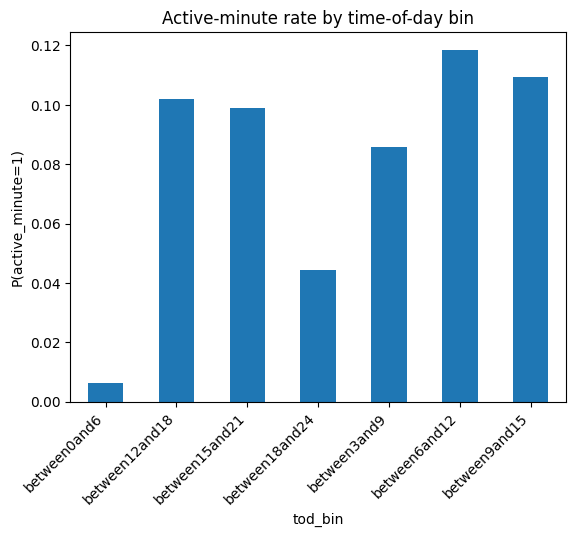

In [ ]:
tod_cols = [c for c in ex.columns if c.startswith("discrete:time_of_day:")]
ex["tod_bin"] = ex[tod_cols].idxmax(axis=1).str.replace("discrete:time_of_day:", "", regex=False)

# Active rate by time bin
tod_active = ex.groupby("tod_bin")["active_minute"].mean().sort_index()
print(tod_active)

# Plot active rate by time bin
plt.figure()
tod_active.plot(kind="bar")
plt.title("Active-minute rate by time-of-day bin")
plt.ylabel("P(active_minute=1)")
plt.xticks(rotation=45, ha="right")
plt.show()

label:WITH_FRIENDS       0.0       1.0
tod_bin                               
between0and6        0.004717  0.058728
between12and18      0.095253  0.185693
between15and21      0.091335  0.158132
between18and24      0.037260  0.120638
between3and9        0.073870  0.399717
between6and12       0.110300  0.257015
between9and15       0.107726  0.130107


<Figure size 640x480 with 0 Axes>

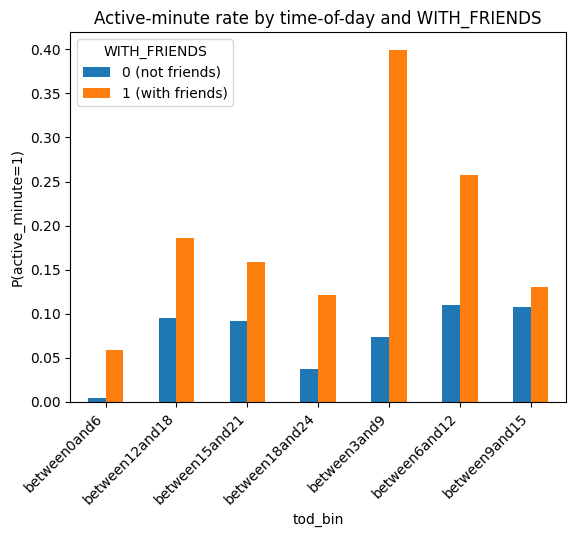

In [16]:
# Friends vs not friends within time bins
pivot = ex.pivot_table(
    index="tod_bin",
    columns="label:WITH_FRIENDS",
    values="active_minute",
    aggfunc="mean"
).sort_index()

print(pivot)

plt.figure()
pivot.plot(kind="bar")
plt.title("Active-minute rate by time-of-day and WITH_FRIENDS")
plt.ylabel("P(active_minute=1)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="WITH_FRIENDS", labels=["0 (not friends)", "1 (with friends)"])
plt.show()

**Envrioment Confunding (home/work/outside)**

label:OR_indoors            0.489450
label:LOC_home              0.405177
label:LOC_main_workplace    0.089955
label:OR_outside            0.032103
dtype: float64

Active rate by WITH_FRIENDS and label:OR_outside
label:WITH_FRIENDS  label:OR_outside
0.0                 0.0                 0.053907
                    1.0                 0.607858
1.0                 0.0                 0.100448
                    1.0                 0.669217
Name: active_minute, dtype: float64

Active rate by WITH_FRIENDS and label:OR_indoors
label:WITH_FRIENDS  label:OR_indoors
0.0                 0.0                 0.115695
                    1.0                 0.020138
1.0                 0.0                 0.252571
                    1.0                 0.044976
Name: active_minute, dtype: float64

Active rate by WITH_FRIENDS and label:LOC_home
label:WITH_FRIENDS  label:LOC_home
0.0                 0.0               0.104316
                    1.0               0.019145
1.0                 0.

<Figure size 640x480 with 0 Axes>

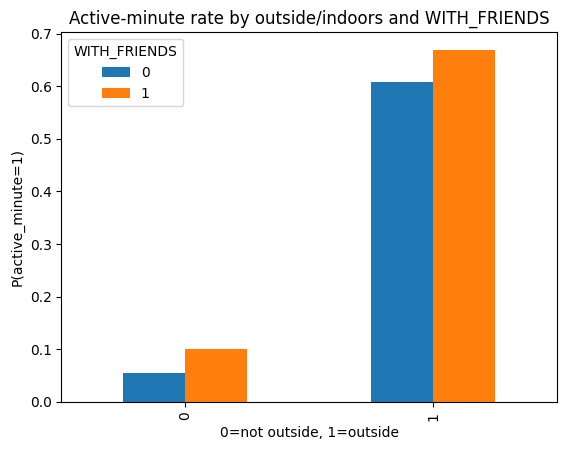

In [18]:
env_cols = ["label:LOC_home","label:LOC_main_workplace","label:OR_outside","label:OR_indoors"]
print(ex[env_cols].mean().sort_values(ascending=False))

# Active by friends within outside vs indoors
for env in ["label:OR_outside", "label:OR_indoors", "label:LOC_home", "label:LOC_main_workplace"]:
    tab = ex.groupby(["label:WITH_FRIENDS", env])["active_minute"].mean()
    print("\nActive rate by WITH_FRIENDS and", env)
    print(tab)

# Plot
df_plot = ex.copy()
df_plot["outside_flag"] = df_plot["label:OR_outside"].astype(int)

plot_tab = df_plot.pivot_table(
    index="outside_flag",
    columns="label:WITH_FRIENDS",
    values="active_minute",
    aggfunc="mean"
)

plt.figure()
plot_tab.plot(kind="bar")
plt.title("Active-minute rate by outside/indoors and WITH_FRIENDS")
plt.xlabel("0=not outside, 1=outside")
plt.ylabel("P(active_minute=1)")
plt.legend(title="WITH_FRIENDS", labels=["0", "1"])
plt.show()

,n_minutes,active_rate,friends_rate,active_not_friends,active_with_friends,within_user_diff
count,60.000000,60.000000,60.000000,60.000000,32.000000,32.000000
mean,6289.100000,0.076705,0.065501,0.072033,0.189705,0.117308
std,2482.909684,0.044922,0.107134,0.044849,0.259998,0.266853
min,1600.000000,0.004812,0.000000,0.001035,0.000000,-0.173096
25%,3947.750000,0.041576,0.000000,0.040199,0.013122,-0.038661
50%,6312.500000,0.069072,0.003814,0.059887,0.105670,0.022363
75%,8177.750000,0.104574,0.083166,0.099246,0.218773,0.165769
max,11996.000000,0.203696,0.416162,0.203018,1.000000,0.998965


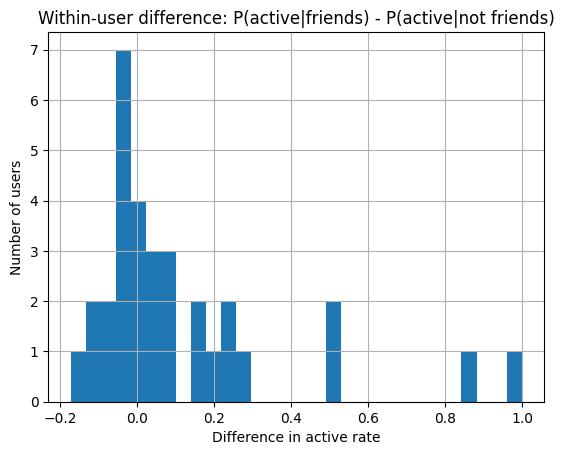

In [19]:
# User-level variability (justifies mixed effects)
user_summary = ex.groupby("user_id").agg(
    n_minutes=("active_minute","size"),
    active_rate=("active_minute","mean"),
    friends_rate=("label:WITH_FRIENDS","mean")
)

# Within-user active rates for friends vs not friends
tmp = ex.groupby(["user_id","label:WITH_FRIENDS"])["active_minute"].mean().unstack()
tmp.columns = ["active_not_friends","active_with_friends"]
user_summary = user_summary.join(tmp)

user_summary["within_user_diff"] = user_summary["active_with_friends"] - user_summary["active_not_friends"]

display(user_summary.describe())

plt.figure()
user_summary["within_user_diff"].dropna().hist(bins=30)
plt.title("Within-user difference: P(active|friends) - P(active|not friends)")
plt.xlabel("Difference in active rate")
plt.ylabel("Number of users")
plt.show()

#### NOAA Weather EDA (secondary dataset)

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

DATE         0.0
TMP_value    0.0
dtype: float64
count    11752.000000
mean        19.252519
std          4.231847
min          5.000000
25%         16.700000
50%         18.900000
75%         22.200000
max         35.600000
Name: TMP_value, dtype: float64


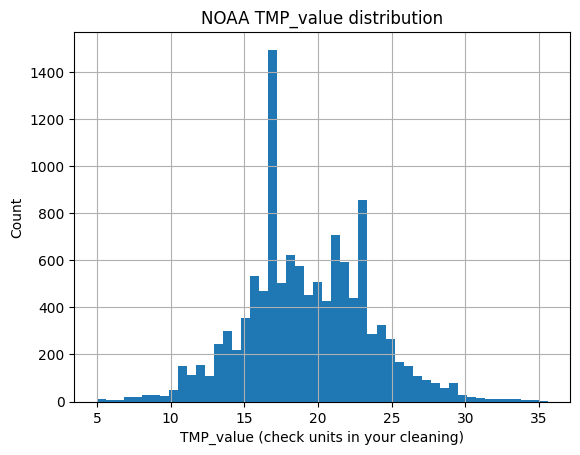

In [20]:
# Keep only what we need for EDA
noaa = temp[["DATE", "TMP_value", "STATION"]].copy()

# Parse datetime
noaa["DATE"] = pd.to_datetime(noaa["DATE"], errors="coerce")

# TMP_value should be numeric
noaa["TMP_value"] = pd.to_numeric(noaa["TMP_value"], errors="coerce")

print(noaa[["DATE","TMP_value"]].isna().mean())
print(noaa["TMP_value"].describe())

plt.figure()
noaa["TMP_value"].dropna().hist(bins=50)
plt.title("NOAA TMP_value distribution")
plt.xlabel("TMP_value (check units in your cleaning)")
plt.ylabel("Count")
plt.show()

#### Holiday / non-workdays EDA (third dataset)

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [21]:
holi["date"] = pd.to_datetime(holi["date"], errors="coerce")
print(holi.shape)
print("Unique holiday dates:", holi["date"].nunique())
display(holi.head())

(114, 2)
Unique holiday dates: 114


,date,holidayName
0,2015-01-01,New Year's Day
1,2015-01-03,Weekend
2,2015-01-04,Weekend
3,2015-01-10,Weekend
4,2015-01-11,Weekend


#### Merge EDA

ExtraSensory processed file has only timestamp and no lat/long. That means you can only merge weather if you already decided on a single station/region and align by time. If your NOAA data is for one station (or a known area), this is fine.

In [24]:
ex2 = ex.copy()
ex2["datetime"] = pd.to_datetime(ex2["timestamp"], unit="s", errors="coerce")  # if timestamp is seconds
# If it looks wrong (all NaT), try unit="ms"

ex2["date"] = ex2["datetime"].dt.normalize()
holi2 = holi.copy()
holi2["date"] = pd.to_datetime(holi2["date"]).dt.normalize()

ex2 = ex2.merge(holi2[["date","holidayName"]], on="date", how="left")
ex2["is_holiday"] = ex2["holidayName"].notna().astype(int)

print("Holiday match rate:", ex2["is_holiday"].mean())
ex2[["date","is_holiday","holidayName"]].head()

Holiday match rate: 0.25733676784701576


,date,is_holiday,holidayName
0,2015-10-05,0,NaN
1,2015-10-05,0,NaN
2,2015-10-05,0,NaN
3,2015-10-05,0,NaN
4,2015-10-05,0,NaN


Weather match rate: 0.9394057443301373
temp_bin
(7.199, 17.2]    0.059660
(17.2, 21.1]     0.068075
(21.1, 22.8]     0.064820
(22.8, 25.0]     0.081488
(25.0, 35.6]     0.090284
Name: active_minute, dtype: float64


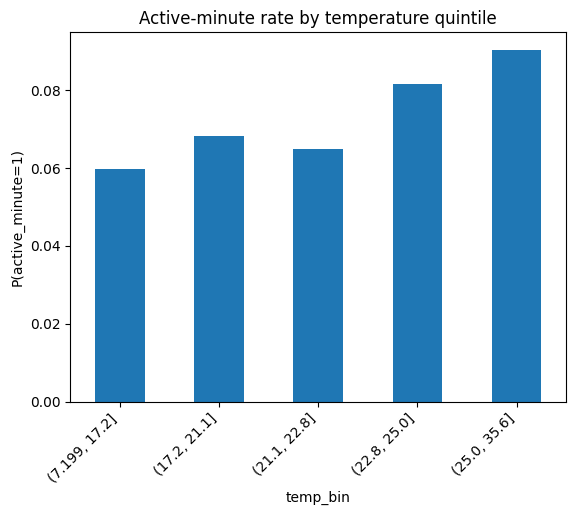

In [26]:
# Round ex2 to hour, and noaa to hour
ex2["hour"] = ex2["datetime"].dt.floor("h")
noaa2 = noaa.dropna(subset=["DATE"]).copy()
noaa2["hour"] = noaa2["DATE"].dt.floor("h")

# If NOAA includes multiple stations, pick one station or average across stations per hour
noaa_hourly = noaa2.groupby("hour")["TMP_value"].mean().reset_index()

ex2 = ex2.merge(noaa_hourly, on="hour", how="left")
print("Weather match rate:", ex2["TMP_value"].notna().mean())

# EDA: active rate vs temperature bins
ex2["temp_bin"] = pd.qcut(ex2["TMP_value"], 5, duplicates="drop")
temp_active = ex2.groupby("temp_bin")["active_minute"].mean()
print(temp_active)

plt.figure()
temp_active.plot(kind="bar")
plt.title("Active-minute rate by temperature quintile")
plt.ylabel("P(active_minute=1)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: We are not collecting data from participants ourselves. If the dataset contains human-related records, we will only use sources that were collected by the original providers under their stated terms of use and consent processes. We will not attempt to re-identify individuals or merge in additional data to identify people.

 - [X] **A.2 Collection bias**: This is relevant because observational/public datasets often over-represent certain groups, locations, or time periods. We will inspect basic distributions (for example, geography, time, or demographic proxies if present) and explicitly discuss how any skews could affect conclusions. If strong imbalance exists, we will use appropriate stratified evaluation and avoid making “population-wide” claims.

 - [X] **A.3 Limit PII exposure**: This is relevant. We will not use direct identifiers (names, exact addresses, phone numbers, email addresses, student identifiers, account identifiers). If any appear, we will drop them immediately and ensure no outputs contain row-level information that could identify an individual. We will only report aggregated results and summary statistics.

 - [X] **A.4 Downstream bias mitigation**: If protected attributes are present, we will be cautious about how they are used (for example, not using them as targets or as proxies for targeting). If protected attributes are not present, we will still consider proxy variables (for example, ZIP code as a proxy for race/income) and discuss this limitation.

### B. Data Storage
 - [X] **B.1 Data security**: We will keep data in our private course repository / local machines with restricted access to team members only. If the dataset includes any sensitive fields, we will store only the minimum needed columns, avoid sharing raw data in public locations, and avoid uploading raw files outside the class workflow.

 - [ ] **B.2 Right to be forgotten**: Not applicable for our use if the dataset is fully public, de-identified, and we do not maintain a system of individual accounts or records. If we discover the dataset includes identifiable records, we will not use it.

 - [X] **B.3 Data retention plan**: We will delete local copies of any raw data after the course ends (or earlier if no longer needed), keeping only derived, non-identifying aggregates and our code/notebooks for reproducibility.

### C. Analysis
 - [X] **C.1 Missing perspectives**: This can be relevant because our interpretation may miss important social and structural context beyond how the data were generated. In particular, differences in activity levels by social context may reflect constraints rather than individual preferences, such as living arrangements, caregiving responsibilities, disability, or limited access to social networks. We will cross-check assumptions against dataset documentation and external methodological sources, and we will explicitly discuss which perspectives are not captured in the data (for example, the distinction between choosing to be alone versus being socially constrained). We will caution against interpreting observed patterns as reflecting individual motivation or responsibility alone.

 - [X] **C.2 Dataset bias**: This is relevant. We will check for missingness patterns, imbalanced classes, and potential confounds. Where possible we will run sensitivity checks (for example, compare results across subgroups or time periods) and clearly state when results may be driven by bias or confounding.

 - [X] **C.3 Honest representation**: We will avoid misleading visuals (for example, truncated axes or selectively chosen time windows) and will present uncertainty (such as variability or confidence intervals) where appropriate. In addition, we will be careful with language and framing: we will avoid normative or deficit-based descriptions that could imply that solitary activity is inherently inferior or unhealthy. Our results will be presented as descriptive associations rather than prescriptive guidance, and we will clearly distinguish correlation from causation in both figures and written interpretation.

 - [X] **C.4 Privacy in analysis**: We will not publish raw records, and we will avoid showing small-cell counts that could enable re-identification. Any examples shown will be synthetic or heavily aggregated.

 - [X] **C.5 Auditability**: We will keep a clear, reproducible pipeline (data cleaning steps, feature engineering, modeling code, and random seeds), and we will document decisions so issues can be traced later.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: If we build predictive models, we will review features for potential proxies for protected characteristics and avoid using features that create discriminatory outcomes without strong justification.

 - [X] **D.2 Fairness across groups**: If group labels exist (or reasonable proxies), we will compare error rates across groups. If they do not exist, we will note that fairness testing is limited.

 - [X] **D.3 Metric selection**: We will not rely on a single metric. For classification, we will report multiple metrics (for example, precision, recall, and calibration where relevant) and justify the metric choice based on the project goal.

 - [X] **D.4 Explainability**: We will prefer interpretable baselines (for example, linear/logistic models) and use feature importance or partial dependence plots if we use more complex models, so our conclusions can be explained.

 - [X] **D.5 Communicate limitations**: We will clearly describe limitations (data coverage, bias, confounding, and generalizability) and avoid overstating claims (especially causal claims from correlational data).

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Not applicable because we are not deploying a system in production.

 - [ ] **E.2 Redress**: Not applicable because we are not deploying a system that affects users directly.

 - [ ] **E.3 Roll back**: Not applicable because we are not deploying.

 - [X] **E.4 Unintended use**: This is relevant. Findings from this project could be interpreted in public health or media contexts to suggest that higher physical activity requires social companionship, which risks stigmatizing individuals who live alone or lack access to social support. Such interpretations may shift responsibility onto individuals while overlooking structural constraints (for example, living arrangements, caregiving responsibilities, disability, or social isolation). We therefore emphasize that our analysis is descriptive and correlational rather than prescriptive or causal. In our reporting, we will avoid normative language and frame social context as a facilitating factor rather than a benchmark for “healthy” behavior. We will also explicitly state that public health interventions should consider multiple pathways to physical activity, including options that support individuals who are active alone.

## Team Expectations 

* Our team agrees to maintain open, respectful, and consistent communication throughout the quarter, and to foster an environment in which all members feel comfortable sharing their ideas and perspectives. We will primarily communicate through WeChat and hold regular meetings to report progress and coordinate next steps. All members are expected to respond to group messages within

* If conflicts arise, we will address them through open and respectful discussion, with an emphasis on mutual understanding. If necessary, we will seek guidance from the TA or instructor. Each member is expected to complete assigned tasks on time and contribute to the team’s overall progress. If difficulties or unforeseen issues arise, members are expected to communicate promptly and support one another in finding solutions.

* Tasks will be assigned based on individual strengths and interests; however, all members are expected to actively participate in group discussions and decision-making regarding the project direction, research questions, and methods. Throughout the research process, we commit to upholding academic integrity and ethical considerations, and to working toward meaningful and responsible outcome.

## Project Timeline Proposal

3/3 7:00 PM
(Before) Finalize EDA and begin main analysis
(Discuss) Discuss and edit analysis results; check overall project progress

3/10 7:00 PM
(Before) Complete analysis and draft results and discussion sections
(Discuss) Review and edit the full project; finalize video content plan

Final Deadline Before 11:59 PM
(Before) Finalize the written report, visualizations, and project video
(Discuss) Submit the final project and complete group project surveys